In [1]:
import numpy as np
from pathlib import Path

from functions import *

from minerva.transforms.transform import *
from minerva.transforms.random_transform import *

from minerva.data.readers import TiffReader, NumpyArrayReader
from minerva.data.datasets import SimpleDataset
from minerva.data.data_modules import MinervaDataModule

from minerva.models.ssl.byol import BYOL
from minerva.models.nets.image.deeplabv3 import DeepLabV3Backbone

from minerva.pipelines.lightning_pipeline import SimpleLightningPipeline
from lightning.pytorch.loggers.csv_logs import CSVLogger
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning import Trainer

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
input_size = (256, 256)
dataset_name = 'f3'
batch_size = 8
num_epochs = 20
repetition = 0
learning_rate = 0.001
# data_path = "/workspaces/shared_data/seismic/f3_segmentation_N"

# data_path = "/workspaces/shared_data/seismic/f3_segmentation"

# data_path = "/workspaces/shared_data/seam_ai_datasets/seam_ai"

data_path = "/workspaces/shared_data/seam_ai_datasets/seam_ai_N"
ckpt_path = None
log_path = None
gpus = [0]

In [3]:
random_flip = RandomFlip(possible_axis=[1])
random_crop = RandomCrop(crop_size=input_size)
random_rotation = RandomRotation(degrees=25, prob=0.2)
transpose_to_HWC = Transpose([1, 2, 0])
transpose_to_CHW = Transpose([2, 0, 1])    
cast_to_tensor = CastTo(dtype=np.float32)
repeat = Repeat(axis=2, n_repetitions=3)

In [4]:
byol_transform_pipeline = TransformPipeline([
    random_crop,
    random_flip,
    random_rotation,
    transpose_to_CHW,
    cast_to_tensor,
])

constrastive_transform = ContrastiveTransform(byol_transform_pipeline)

In [5]:
train_img_reader = TiffReader(path=data_path)

pretrain_dataset = SimpleDataset(
    readers=train_img_reader,
    transforms=constrastive_transform,
    return_single=True
)

data_module = MinervaDataModule(
    train_dataset=pretrain_dataset,
    batch_size=batch_size,
    drop_last=True,
    shuffle_train=True,
    name=dataset_name
)

In [6]:
loader = data_module.train_dataloader()
batch = next(iter(loader))
len(batch)

2

In [7]:
batch[0][0].shape

torch.Size([3, 256, 256])

In [8]:
batch[1][0].shape

torch.Size([3, 256, 256])

Figure saved as 'outputs/images.png'


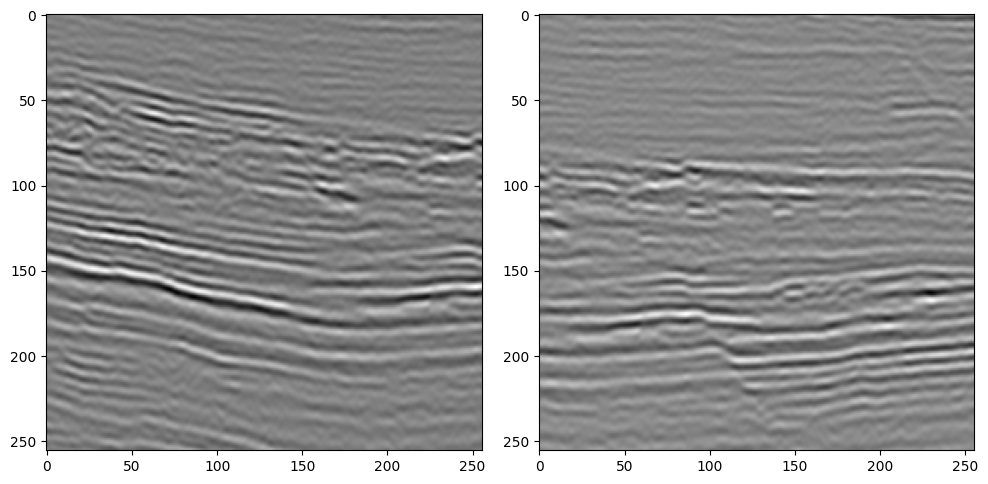

In [9]:
plot_images([
    batch[0][4][0],
    batch[1][4][0]],
    filename="outputs/images.png"
            )

In [10]:
import torchvision.models.segmentation as models
import torch
import torchvision
from torchvision.models.resnet import resnet50
import torch.nn as nn



In [11]:
state_dict1 = torch.hub.load("pytorch/vision:v0.10.0", "deeplabv3_resnet50", pretrained=True).backbone.state_dict()
state_dict2 = models.deeplabv3_resnet50(weights="COCO_WITH_VOC_LABELS_V1").backbone.state_dict()

for k1, k2 in zip(state_dict1.values(), state_dict2.values()):
    if not torch.allclose(k1, k2, atol=1e-7):
        print("❌ Difference found")
        break
else:
    print("✅ Weights are identical")


Downloading: "https://github.com/pytorch/vision/zipball/v0.10.0" to /home/vscode/.cache/torch/hub/v0.10.0.zip


/home/vscode/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vscode/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /home/vscode/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:01<00:00, 113MB/s]  


✅ Weights are identical


In [12]:
weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V2
backbone_2 = resnet50(
    replace_stride_with_dilation=[False, True, True], weights=weights
)
state_dict1 = backbone_2.state_dict()

weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V1
backbone_1 = resnet50(
    replace_stride_with_dilation=[False, True, True], weights=weights
)

state_dict2 = backbone_2.state_dict()


for k1, k2 in zip(state_dict1.values(), state_dict2.values()):
    if not torch.allclose(k1, k2, atol=1e-7):
        print("❌ Difference found")
        break
else:
    print("✅ Weights are identical")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/vscode/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 112MB/s] 


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/vscode/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 113MB/s]


✅ Weights are identical


In [13]:
from functions import *

In [14]:
sup_model = get_model(    
    'sup',
    0.001,
    False,
    0
)
sup_state_dict = sup_model.state_dict()


2025-05-19 19:07:47 - minerva - INFO - No model loaded!


In [15]:
from torchinfo import summary

# Display the summary of the model
summary(sup_model, input_size=(2, 3, 256, 256), device="cpu")

Layer (type:depth-idx)                             Output Shape              Param #
DeepLabV3                                          [2, 6, 256, 256]          --
├─DeepLabV3Backbone: 1-1                           [2, 2048, 32, 32]         --
│    └─ResNet: 2-1                                 --                        2,049,000
│    │    └─Conv2d: 3-1                            [2, 64, 128, 128]         9,408
│    │    └─BatchNorm2d: 3-2                       [2, 64, 128, 128]         128
│    │    └─ReLU: 3-3                              [2, 64, 128, 128]         --
│    │    └─MaxPool2d: 3-4                         [2, 64, 64, 64]           --
│    │    └─Sequential: 3-5                        [2, 256, 64, 64]          215,808
│    │    └─Sequential: 3-6                        [2, 512, 32, 32]          1,219,584
│    │    └─Sequential: 3-7                        [2, 1024, 32, 32]         7,098,368
│    │    └─Sequential: 3-8                        [2, 2048, 32, 32]         14,964,7

In [16]:
imagenet_model = get_model(
    'imagenet',
    0.001,
    False,
    0    
)
imagenet_state_dict = imagenet_model.state_dict()

2025-05-19 19:07:48 - minerva - INFO - IMAGENET backbone loaded


In [17]:
summary(imagenet_model, input_size=(2, 3, 256, 256), device="cpu")

Layer (type:depth-idx)                             Output Shape              Param #
DeepLabV3                                          [2, 6, 256, 256]          --
├─Sequential: 1-1                                  [2, 2048, 32, 32]         --
│    └─Conv2d: 2-1                                 [2, 64, 128, 128]         9,408
│    └─BatchNorm2d: 2-2                            [2, 64, 128, 128]         128
│    └─ReLU: 2-3                                   [2, 64, 128, 128]         --
│    └─MaxPool2d: 2-4                              [2, 64, 64, 64]           --
│    └─Sequential: 2-5                             [2, 256, 64, 64]          --
│    │    └─Bottleneck: 3-1                        [2, 256, 64, 64]          75,008
│    │    └─Bottleneck: 3-2                        [2, 256, 64, 64]          70,400
│    │    └─Bottleneck: 3-3                        [2, 256, 64, 64]          70,400
│    └─Sequential: 2-6                             [2, 512, 32, 32]          --
│    │    └─Bottlen

In [18]:
coco_model = get_model(
    'coco',
    0.001,
    False,
    0
)

coco_state_dict = coco_model.state_dict()

Using cache found in /home/vscode/.cache/torch/hub/pytorch_vision_v0.10.0
2025-05-19 19:07:49 - minerva - INFO - COCO backbone loaded


In [19]:
# class SummaryWrapper(nn.Module):
#     def __init__(self, model):
#         super().__init__()
#         self.model = model

#     def forward(self, x):
#         out = self.model.backbone(x)
#         return out["out"] if isinstance(out, OrderedDict) else out

In [20]:
summary(coco_model, input_size=(2, 3, 256, 256), device="cpu")  # batch_size incluído!


Layer (type:depth-idx)                             Output Shape              Param #
DeepLabV3                                          [2, 6, 256, 256]          --
├─IntermediateLayerGetter: 1-1                     [2, 2048, 32, 32]         --
│    └─Conv2d: 2-1                                 [2, 64, 128, 128]         9,408
│    └─BatchNorm2d: 2-2                            [2, 64, 128, 128]         128
│    └─ReLU: 2-3                                   [2, 64, 128, 128]         --
│    └─MaxPool2d: 2-4                              [2, 64, 64, 64]           --
│    └─Sequential: 2-5                             [2, 256, 64, 64]          --
│    │    └─Bottleneck: 3-1                        [2, 256, 64, 64]          75,008
│    │    └─Bottleneck: 3-2                        [2, 256, 64, 64]          70,400
│    │    └─Bottleneck: 3-3                        [2, 256, 64, 64]          70,400
│    └─Sequential: 2-6                             [2, 512, 32, 32]          --
│    │    └─Bottlen

In [21]:
# summary(SummaryWrapper(coco_model), input_size=(3, 256, 256), device="cpu")

In [22]:
f3_model = get_model(
    'f3', 
    0.001,
    False,
    0
)
f3_state_dict = f3_model.state_dict()

2025-05-19 19:07:54 - minerva - INFO - f3 backbone loaded


Model loaded from ckpt/pretrain/0/V0_pretrain_f3_In256_B32_E500/f3/last.ckpt


In [23]:
summary(f3_model, input_size=(2, 3, 256, 256), device="cpu")  # batch_size incluído!


Layer (type:depth-idx)                             Output Shape              Param #
DeepLabV3                                          [2, 6, 256, 256]          --
├─DeepLabV3Backbone: 1-1                           [2, 2048, 32, 32]         --
│    └─ResNet: 2-1                                 --                        2,049,000
│    │    └─Conv2d: 3-1                            [2, 64, 128, 128]         9,408
│    │    └─BatchNorm2d: 3-2                       [2, 64, 128, 128]         128
│    │    └─ReLU: 3-3                              [2, 64, 128, 128]         --
│    │    └─MaxPool2d: 3-4                         [2, 64, 64, 64]           --
│    │    └─Sequential: 3-5                        [2, 256, 64, 64]          215,808
│    │    └─Sequential: 3-6                        [2, 512, 32, 32]          1,219,584
│    │    └─Sequential: 3-7                        [2, 1024, 32, 32]         7,098,368
│    │    └─Sequential: 3-8                        [2, 2048, 32, 32]         14,964,7

In [24]:
for key in sup_state_dict.keys() & coco_state_dict.keys():
    if not torch.allclose(sup_state_dict[key], coco_state_dict[key], atol=1e-7):
        print(f"❌ Difference found in key: {key}")
        print(f"sup_state_dict[{key}]: {sup_state_dict[key].name}")
        print(f"coco_state_dict[{key}]: {coco_state_dict[key].name}")
    # else:
    #     print("✅ All matching keys have identical values")

❌ Difference found in key: fc.0.convs.4.1.weight
sup_state_dict[fc.0.convs.4.1.weight]: None
coco_state_dict[fc.0.convs.4.1.weight]: None
❌ Difference found in key: fc.0.convs.2.0.weight
sup_state_dict[fc.0.convs.2.0.weight]: None
coco_state_dict[fc.0.convs.2.0.weight]: None
❌ Difference found in key: fc.0.convs.0.0.weight
sup_state_dict[fc.0.convs.0.0.weight]: None
coco_state_dict[fc.0.convs.0.0.weight]: None
❌ Difference found in key: fc.0.project.0.weight
sup_state_dict[fc.0.project.0.weight]: None
coco_state_dict[fc.0.project.0.weight]: None
❌ Difference found in key: fc.1.weight
sup_state_dict[fc.1.weight]: None
coco_state_dict[fc.1.weight]: None
❌ Difference found in key: fc.0.convs.3.0.weight
sup_state_dict[fc.0.convs.3.0.weight]: None
coco_state_dict[fc.0.convs.3.0.weight]: None
❌ Difference found in key: fc.0.convs.1.0.weight
sup_state_dict[fc.0.convs.1.0.weight]: None
coco_state_dict[fc.0.convs.1.0.weight]: None
❌ Difference found in key: fc.4.bias
sup_state_dict[fc.4.bias]: 

In [25]:
import torch

def compare_model_layers(state_dict1, state_dict2, atol=1e-7):
    """
    Compare two model state dictionaries and print differences in layers, independent of their names.

    Args:
        state_dict1 (OrderedDict): State dictionary of the first model.
        state_dict2 (OrderedDict): State dictionary of the second model.
        atol (float): Absolute tolerance for comparison.

    Returns:
        None
    """
    layers1 = list(state_dict1.values())
    layers2 = list(state_dict2.values())

    min_len = min(len(layers1), len(layers2))

    for i in range(min_len):
        if not torch.allclose(layers1[i], layers2[i], atol=atol):
            print(f"❌ Difference found in layer {i}")
            print(f"Layer {i} in model 1: {layers1[i].shape}")
            print(f"Layer {i} in model 2: {layers2[i].shape}")
            return

    if len(layers1) > len(layers2):
        print(f"Model 1 has {len(layers1) - len(layers2)} extra layers.")
    elif len(layers2) > len(layers1):
        print(f"Model 2 has {len(layers2) - len(layers1)} extra layers.")
    else:
        print("✅ All layers match within the given tolerance.")

# Example usage:
compare_model_layers(sup_state_dict, coco_state_dict)

❌ Difference found in layer 0
Layer 0 in model 1: torch.Size([64, 3, 7, 7])
Layer 0 in model 2: torch.Size([64, 3, 7, 7])


In [26]:
compare_model_layers(sup_state_dict, f3_state_dict)

❌ Difference found in layer 0
Layer 0 in model 1: torch.Size([64, 3, 7, 7])
Layer 0 in model 2: torch.Size([64, 3, 7, 7])


In [27]:
compare_model_layers(f3_state_dict, imagenet_state_dict)

❌ Difference found in layer 0
Layer 0 in model 1: torch.Size([64, 3, 7, 7])
Layer 0 in model 2: torch.Size([64, 3, 7, 7])


In [28]:
compare_model_layers(coco_state_dict, imagenet_state_dict)

❌ Difference found in layer 0
Layer 0 in model 1: torch.Size([64, 3, 7, 7])
Layer 0 in model 2: torch.Size([64, 3, 7, 7])


In [29]:
import torch
from torch import nn
from torch.nn import functional as F
from typing import Sequence
from torchvision.models.resnet import resnet50
import lightning as L
from torchvision.models.segmentation.deeplabv3 import ASPP
from torchmetrics import JaccardIndex, F1Score
from collections import OrderedDict
import torchvision


@torch.no_grad()
def deactivate_requires_grad(model: nn.Module):
    """Deactivates the requires_grad flag for all parameters of a model."""
    for param in model.parameters():
        param.requires_grad = False


class DeepLabV3Model(L.LightningModule):
    def __init__(
        self,
        backbone=None,
        pred_head=None,
        num_classes=6,
        learning_rate=0.001,
        freeze_backbone=False,
    ):
        super().__init__()
        self.backbone = backbone if backbone else DeepLabV3Backbone()
        self.pred_head = (
            pred_head if pred_head else DeepLabV3PredictionHead(num_classes=num_classes)
        )
        self.loss_fn = torch.nn.CrossEntropyLoss(
            # class_weight = [0.0456399, 0.1064931, 0.02634881, 0.1825596, 0.4259724, 0.2129862]
        )
        # class_weight = [0.0456399, 0.1064931, 0.02634881, 0.1825596, 0.4259724, 0.2129862]
        self.learning_rate = learning_rate
        if freeze_backbone:
            deactivate_requires_grad(self.backbone)

        self.IoU = JaccardIndex(num_classes=num_classes, task="multiclass")
        self.F1 = F1Score(num_classes=num_classes, task="multiclass")

    # def forward(self, x):
    #     input_shape = x.shape[-2:]
    #     h = self.backbone(x)
    #     z = self.pred_head(h)
    #     # Upscaling
    #     return F.interpolate(z, size=input_shape, mode="bilinear", align_corners=False)

    def forward(self, x):
        input_shape = x.shape[-2:]  # Save the original input shape
        features = self.backbone(x)
        if isinstance(features, OrderedDict):
            features = features["out"]
        x = self.pred_head(features)
        return F.interpolate(x, size=input_shape, mode="bilinear", align_corners=False)

    def training_step(self, batch, batch_idx):
        X, y = batch
        logits = self.forward(X.float())
        loss = self.loss_fn(logits, y.squeeze(1).to(torch.long))

        pred = torch.argmax(logits, dim=1, keepdim=True)

        f1 = self.F1(pred, y)
        IoU = self.IoU(pred, y)

        self.log("train_loss", loss)
        self.log("train_F1", f1)
        self.log("train_IoU", IoU)
        return loss

    def validation_step(self, batch, batch_idx):
        X, y = batch
        logits = self.forward(X.float())
        val_loss = self.loss_fn(logits, y.squeeze(1).to(torch.long))

        pred = torch.argmax(logits, dim=1, keepdim=True)

        val_f1 = self.F1(pred, y)
        val_IoU = self.IoU(pred, y)

        self.log("val_loss", val_loss)
        self.log("val_F1", val_f1)
        self.log("val_IoU", val_IoU)
        return val_loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(params=self.parameters(), lr=self.learning_rate)
        return optimizer


class DeepLabV3Backbone(nn.Module):
    def __init__(self, num_classes=6, pretrain=""):
        super().__init__()
        if pretrain == "":
            print("********** Backbone from scratch carregado **********")
            self.RN50model = resnet50(replace_stride_with_dilation=[False, True, True])
        elif pretrain == "imagenet":
            print("********** Backbone IMAGENET carregado **********")
            weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V1
            self.RN50model = resnet50(
                replace_stride_with_dilation=[False, True, True], weights=weights
            )

    def freeze_weights(self):
        for param in self.RN50model.parameters():
            param.requires_grad = False

    def unfreeze_weights(self):
        for param in self.RN50model.parameters():
            param.requires_grad = True

    def forward(self, x):
        x = self.RN50model.conv1(x)
        x = self.RN50model.bn1(x)
        x = self.RN50model.relu(x)
        x = self.RN50model.maxpool(x)
        x = self.RN50model.layer1(x)
        x = self.RN50model.layer2(x)
        x = self.RN50model.layer3(x)
        x = self.RN50model.layer4(x)
        # x = self.RN50model.avgpool(x)      # These should be removed for deeplabv3
        # x = torch.RN50model.flatten(x, 1)  # These should be removed for deeplabv3
        # x = self.RN50model.fc(x)           # These should be removed for deeplabv3
        return x


class DeepLabV3PredictionHead(nn.Sequential):
    def __init__(
        self,
        in_channels: int = 2048,
        num_classes: int = 6,
        atrous_rates: Sequence[int] = (12, 24, 36),
    ) -> None:
        super().__init__(
            ASPP(in_channels, atrous_rates),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, num_classes, 1),
        )


In [30]:
import torch
import lightning as L
import torchvision

from torch.nn import functional as F
from torch import nn
from torchmetrics import JaccardIndex, F1Score
from collections import OrderedDict


# --- Utilities ---------------------------------------------------------


@torch.no_grad()
def deactivate_requires_grad(model: nn.Module):
    """Deactivates the requires_grad flag for all parameters of a model."""
    for param in model.parameters():
        param.requires_grad = False


# --- Model Parts ---------------------------------------------------------


class PredictionHead(nn.Module):
    """Predction Head for downstream task.
    Upsamples the features from the backbone in a series of ConvTranspose2d layers
    They add up to 16x the original size of the input.
    Projects the number of in_channels to the number of classes.
    """

    def __init__(self, num_classes=6, in_channels=2048):
        super().__init__()
        self.upsample1 = nn.ConvTranspose2d(
            in_channels, 512, kernel_size=4, stride=2, padding=1
        )
        self.upsample2 = nn.ConvTranspose2d(
            512, num_classes, kernel_size=4, stride=2, padding=1
        )

    def forward(self, x):
        x = self.upsample1(x)
        x = self.upsample2(x)
        return x


# --- Class implementation ----------------------------------------------------------


class SegmentationModel(L.LightningModule):
    """Segmentation Model for downstream task.
    Combines the backbone and the prediction head.
    """

    def __init__(
        self,
        num_classes=6,
        backbone=None,
        head=None,
        loss_fn=None,
        learning_rate=0.001,
        freeze_backbone=False,
    ):

        super().__init__()
        self.backbone = backbone if backbone else DeepLabV3Backbone()
        self.prediction_head = (
            head if head else DeepLabV3PredictionHead(num_classes=num_classes)
        )
        self.loss_fn = (
            loss_fn
            if loss_fn
            else torch.nn.CrossEntropyLoss(
                class_weight=[
                    0.0456399,
                    0.1064931,
                    0.02634881,
                    0.1825596,
                    0.4259724,
                    0.2129862,
                ]
            )
        )
        self.lr = learning_rate

        self.IoU = JaccardIndex(num_classes=num_classes, task="multiclass")
        self.F1 = F1Score(num_classes=num_classes, task="multiclass")

        self.freeze_backbone = freeze_backbone
        if self.freeze_backbone:
            deactivate_requires_grad(self.backbone)

    def forward(self, x):
        input_shape = x.shape[-2:]  # Save the original input shape
        features = self.backbone(x)
        if isinstance(features, OrderedDict):
            features = features["out"]
        x = self.prediction_head(features)
        return F.interpolate(x, size=input_shape, mode="bilinear", align_corners=False)

    def training_step(self, batch, batch_idx):
        X, y = batch
        y_hat = self.forward(X)

        # Compute the loss
        y = y.squeeze(1).to(torch.long)
        loss = self.loss_fn(y_hat, y)
        IoU = self.IoU(y_hat, y)
        F1 = self.F1(y_hat, y)

        self.log("train_loss", loss, sync_dist=True)
        self.log("train_IoU", IoU, sync_dist=True)
        self.log("tain_F1", F1, sync_dist=True)
        return loss

    def validation_step(self, batch, batch_idx):
        X, y = batch
        y_hat = self.forward(X)

        y = y.squeeze(1).to(torch.long)
        val_loss = self.loss_fn(y_hat, y)
        val_IoU = self.IoU(y_hat, y)
        val_F1 = self.F1(y_hat.argmax(dim=1), y)

        self.log("val_loss", val_loss, sync_dist=True)
        self.log("val_IoU", val_IoU, sync_dist=True)
        self.log("val_F1", val_F1, sync_dist=True)
        return val_loss

    def test_step(self, batch, batch_idx):
        X, y = batch
        y_hat = self.forward(X)

        y = y.squeeze(1).to(torch.long)
        test_loss = self.loss_fn(y_hat, y)
        test_IoU = self.IoU(y_hat, y)
        test_F1 = self.F1(y_hat.argmax(dim=1), y)

        self.log("test_loss", test_loss, sync_dist=True)
        self.log("test_IoU", test_IoU, sync_dist=True)
        self.log("test_F1", test_F1, sync_dist=True)
        return test_loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(
            params=self.parameters(), lr=self.lr, weight_decay=0.0005
        )
        return optimizer


In [31]:
def load_pretrained_backbone(
    pretrained_backbone_checkpoint_filename=None, mode: str = "byol"
):

    # backbone direto do pytorch
    backbone = models.deeplabv3_resnet50().backbone

    if mode == "byol":
        print("**********Backbone carregado **********")
        backbone.load_state_dict(torch.load(pretrained_backbone_checkpoint_filename))

    elif mode == "supervised":
        print("********** Backbone from scratch **********")
        # Nenhum peso carregado no backbone

    elif mode == "coco":
        print("********** Backbone COCO carregado **********")
        backbone = models.deeplabv3_resnet50(weights="COCO_WITH_VOC_LABELS_V1").backbone

    elif mode == "imagenet":
        print("********** Backbone IMAGENET carregado **********")
        backbone = DeepLabV3Backbone(num_classes=6, pretrain="imagenet")

    elif mode == "seg":
        print("********** Backbone Segmentation **********")
        pred_head = DeepLabV3PredictionHead(num_classes=6)
        downstream_model = SegmentationModel.load_from_checkpoint(
            pretrained_backbone_checkpoint_filename,
            num_classes=6,
            backbone=backbone,
            head=pred_head,
            loss_fn=torch.nn.CrossEntropyLoss(),
            learning_rate=0.001,
            freeze_backbone=False,
            map_location="cuda",
        )
        backbone = downstream_model.backbone

    return backbone

In [32]:
model = load_pretrained_backbone(mode="coco")
model

********** Backbone COCO carregado **********


IntermediateLayerGetter(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1

In [33]:
coco_model

DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [34]:
compare_model_layers(model, coco_model)

AttributeError: 'DeepLabV3' object has no attribute 'values'